In [ ]:

from brainspace.plotting import plot_hemispheres
from brainspace.utils.parcellation import map_to_labels
import numpy as np
import pandas as pd
from PIL import Image, ImageOps, ImageDraw, ImageFont
import ana_utils
from matplotlib import pyplot as plt
import scipy as sp
import nilearn as nil
from nilearn import plotting
from scipy.stats import f_oneway
import statsmodels.api as sm
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter
import os
import nibabel as nib
from brainspace.mesh.mesh_io import read_surface
from netneurotools.metrics import *
from scipy.stats import chi2_contingency
from PIL import Image, ImageDraw, ImageFont
import pingouin as pg
global micapipe

HOME = f"D:/Shanghaitec/PROJECT/CSVD_neo"
micapipe = f"D:\Shanghaitec\PROJECT\communication\micapipe-master"
# HOME = f"/home/lingbin/share/CSVD"
# micapipe = f"/home/lingbin/Downloads/micapipe-master"

font_path = f"{HOME}/font/FreeSans.ttf" 

# Assuming you have a sans-serif font installed on your system
# font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 48)
# font_bold = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 56)

font = ImageFont.truetype("C:/Users/Ken/AppData/Local/Microsoft/Windows/Fonts/DejaVuSans.ttf",48)
font_bold = ImageFont.truetype("C:/Users/Ken/AppData/Local/Microsoft/Windows/Fonts/DejaVuSans-Bold.ttf",56)

DISGROUPS =  ana_utils.DISGROUPS
LM_LAB = ana_utils.LM_LAB
CM_ARR =ana_utils.CM_ARR[1:]
CM_NAME_ARR = [cm[0] for cm in CM_ARR]
CM_ARR_SHORT = ana_utils.CM_ARR_SHORT
mean_diff_labs = ana_utils.mean_diff_lab
network_abbreviations = ana_utils.net_abbr
yeo7_dict = ana_utils.YEO7_DICT
net_labs = yeo7_dict.keys()
PLT3 = ana_utils.PAL4
net_labs
network_abbreviations

{'Vis': 'VN',
 'SomMot': 'SMN',
 'DorsAttn': 'DAN',
 'SalVentAttn': 'VAN',
 'Limbic': 'LN',
 'Cont': 'FPC',
 'Default': 'DMN'}

In [3]:

def load_annot(atlas, surf='fsaverage5'):
    '''
    Script that loads the labels of an specific parcellation and generates a midwall mask
    '''

    # Load LEFT annotation file in fsaverage5
    annot_lh_fs5= nib.freesurfer.read_annot(f'{micapipe}/parcellations/lh.{atlas}_mics.annot')

    # Unique number of labels of a given atlas
    Ndim = max(np.unique(annot_lh_fs5[0]))

    if surf == 'fsaverage5':

        # Load RIGHT annotation file in fsaverage5
        annot_rh_fs5= nib.freesurfer.read_annot(f'{micapipe}/parcellations/rh.{atlas}_mics.annot')[0]+Ndim

        # replace with 0 the medial wall of the right labels
        annot_rh_fs5 = np.where(annot_rh_fs5==Ndim, 0, annot_rh_fs5)

        # fsaverage5 labels
        labels = np.concatenate((annot_lh_fs5[0], annot_rh_fs5), axis=0)

    else:
        # Read label for fsLR-32k
        labels = np.loadtxt(open(f'{micapipe}/parcellations/{atlas}_conte69.csv'), dtype=int)

    # mask of the medial wall
    mask = labels != 0

    # Midwall labels of aparc-a2009s are lh=42 and rh=117
    if atlas == 'aparc-a2009s' and surf == 'fsaverage5':
        mask[(labels == 117) | (labels == 42)] = 0

    #print(f'{atlas}; midwall = {Ndim}, length = {str(labels.shape)}')

    return(labels, mask, Ndim)


def plotbrain(cm_mat, out_put_file, vmin , vmax, cmap="RdBu_r", size=(1200, 300), layout_style="row"):
    
    # Load fsaverage5 inflated
    fs5_lh = read_surface(f'{micapipe}/surfaces/fsaverage5/surf/lh.inflated', itype='fs')
    fs5_rh = read_surface(f'{micapipe}/surfaces/fsaverage5/surf/rh.inflated', itype='fs')

    # Load fsaverage5 labels
    labels_fs5, mask_fs5, _ = load_annot("schaefer-200", surf='fsaverage5')

    grad = map_to_labels(cm_mat, labels_fs5, mask=mask_fs5, fill=np.nan)
    plot_hemispheres(
        fs5_lh,
        fs5_rh,
        color_range=(vmin,vmax),
        cmap=cmap,
        array_name=grad,
        size=size,
        nan_color=(255, 255, 255, 1),
        screenshot=True,
        # background=(1,1,1),
        layout_style = layout_style,
        filename=f"{out_put_file}.png",
    )


# Run above

# SUb info

In [4]:
info_tbl=pd.read_csv(f"{HOME}/data/filt_sub_info.csv", encoding="gbk")
info_tbl["gender_dig"] = info_tbl["gender"].apply(lambda x: 1 if x=="M" else 0)
print("age")
display(
info_tbl.groupby("Group")["age"].describe().round(2))

print("gender")
display(
info_tbl.groupby("Group")["gender"].describe().round(2))

print("edu_year")
display(
info_tbl.groupby("Group")["edu_year"].describe().round(2))

print("logwmh")
display(
info_tbl.groupby("Group")["logwmh"].describe().round(2))

print("MMSE")
display(
info_tbl.groupby("Group")["门诊MMSE"].describe().round(2))
print()
print("MoCA")
display(
info_tbl.groupby("Group")["MoCA-merge"].describe().round(2))

age


,count,mean,std,min,25%,50%,75%,max
Group,,,,,,,,
NCI,176.0,66.36,6.72,51.0,62.00,66.0,71.0,84.0
aMCI,116.0,66.36,6.43,51.0,61.75,67.0,71.0,82.0
naMCI,79.0,65.27,6.39,51.0,61.00,65.0,69.5,80.0


gender


,count,unique,top,freq
Group,,,,
NCI,176,2,M,111
aMCI,116,2,M,72
naMCI,79,2,M,41


edu_year


...

,count,mean,std,min,25%,50%,75%,max
Group,,,,,,,,
NCI,80.0,3.92,0.40,3.17,3.61,3.89,4.18,4.73
aMCI,46.0,4.14,0.39,3.06,3.87,4.14,4.47,4.80
naMCI,48.0,3.96,0.42,3.17,3.65,3.94,4.27,4.66


MMSE


,count,mean,std,min,25%,50%,75%,max
Group,,,,,,,,
NCI,175.0,28.41,1.54,22.0,28.0,29.0,30.0,30.0
aMCI,114.0,26.73,1.90,20.0,25.0,27.0,28.0,30.0
naMCI,76.0,27.17,1.89,21.0,26.0,27.0,29.0,30.0



MoCA


,count,mean,std,min,25%,50%,75%,max
Group,,,,,,,,
NCI,175.0,25.93,2.48,18.0,25.0,27.0,28.0,30.0
aMCI,114.0,22.01,3.08,11.0,20.0,22.0,24.0,29.0
naMCI,76.0,21.75,3.56,14.0,19.0,22.0,25.0,27.0


In [23]:

crosstable = pd.crosstab(
    index=info_tbl['Group'],  # 行索引
    columns=info_tbl['gender']  # 列索引
)
chi2, p, dof, expected = chi2_contingency(crosstable)
print(chi2, p)

3.0453195999107634 0.21813093004213957


# Plot mats of typical subject 

In [9]:
figures_to_merge = []

typical_subs = [ 'sub-129','sub-184','sub-164']

for sub_id in typical_subs:
    
    figures_to_merge.append(f"{HOME}/data/cm-fig/{sub_id}-wmh_fg-wei.png")
    for col in CM_NAME_ARR:
        filename = f"{HOME}/data/cm-fig/{sub_id}-wmh_{col}.png"
        figures_to_merge.append(filename)
    figures_to_merge.append(f"{HOME}/data/fc-fig/{sub_id}_fc-wb_schaefer-200.png")
        
ana_utils.plot_create_image_grid(figures_to_merge, 3, len(CM_NAME_ARR)+2, 0, f"{HOME}/figures/typical-wmh.png")

FileNotFoundError: [Errno 2] No such file or directory: 'D:/Shanghaitec/PROJECT/CSVD_neo/data/cm-fig/sub-129-wmh_fg-wei.png'

# Plot flow graphs coupling rsq

['#FA7F6f', '#FFBE7A', '#82B0D2']


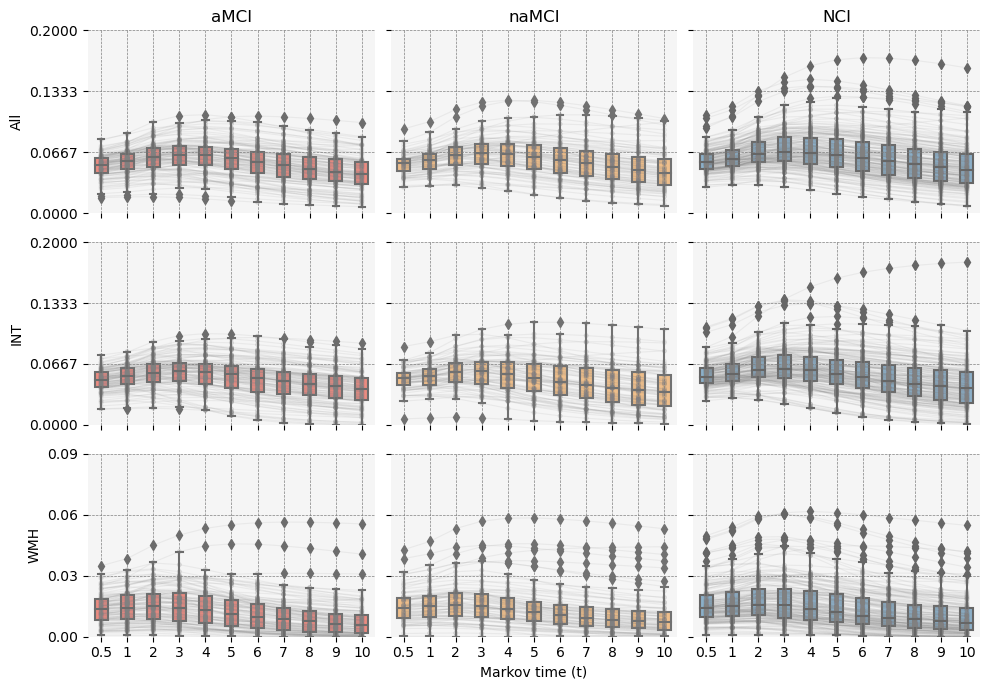

In [34]:
# Paired plot
print(PLT3)
PLT_LOGHT3 = ["#f1aca7", "#fdba9b", "#b9c8df"]
PLT_LOGHT3 = ["gray", "gray", "gray"]
import pingouin as pg
import numpy as np
fig, axes = plt.subplots(3, 3, figsize =(10,7))
# plt.rcParams.update({'font.size': 12}) 

for j, lm_lab in enumerate(LM_LAB):
    for i, group in enumerate(DISGROUPS):
        df = pd.read_csv(f"{HOME}/results/corr_glob_lm_cfc/fg-wei-cfc_{lm_lab}.csv")
        
        df = df[df.Group==group]
        pg.plot_paired(data=df, dv='rsq', within='idx', subject='pid', colors=PLT_LOGHT3, 
                       ax = axes[j, i], 
                       pointplot_kwargs = { "scale": 0.3 ,"marker": ".", "alpha": 0.1 }, 
                       boxplot_kwargs = { "color": PLT3[i],"width": 0.5 })
        
        if i != 0:
            axes[j, i].set_yticklabels([])
            axes[j, i].set_ylabel("")
        else:
            axes[j, i].set_ylabel(["All", "INT","WMH"][j])
        
        if j ==0: # First row
            axes[j, i].set_title(group)
        
        if j ==2: # Last row
            axes[j, i].set_ylim(0.00,0.09)
            axes[j, i].set_yticks((np.linspace(0.00,0.09,num= 4, endpoint= True)))
            axes[j, i].set_xticklabels([0.5, 1,2,3,4,5,6,7,8,9,10])
        else:
            axes[j, i].set_ylim(0.00,0.20)
            axes[j, i].set_yticks((np.linspace(0.00,0.20,num= 4, endpoint= True)))
            
            axes[j, i].set_xticklabels([])
        axes[j, i].set_xlabel("")
        axes[j, i].spines[:].set_visible(False)
        
        axes[2, 1].set_xlabel("Markov time (t)")
        axes[j, i].grid(color = 'gray', linestyle = '--', linewidth = 0.5, which = 'major')
        axes[j, i].set_facecolor("whitesmoke")
        
plt.tight_layout()
plt.savefig(f"{HOME}/figures/flow-graph_marcov.tif", dpi=300 )
plt.show()

# Plot brain network using nilearn
## Global

In [17]:
from nilearn.connectome import ConnectivityMeasure
# from nilearn.maskers import MultiNiftiLabelsMasker
from nilearn import plotting
from nilearn import datasets

shaefer = datasets.fetch_atlas_schaefer_2018(n_rois = 200)
coordinates = plotting.find_parcellation_cut_coords(labels_img=shaefer["maps"])


In [18]:
def fiter_fc(matrix):

    # 找到最大和最小值
    max_val = np.max(matrix)
    min_val = np.min(matrix)

    # 计算阈值
    top_10_percent = 0.05
    top_10_percent_max = max_val - (max_val - min_val) * top_10_percent
    bottom_10_percent_min = min_val + (max_val - min_val) * top_10_percent

    # 置为0
    matrix[(matrix > top_10_percent_max) | (matrix < bottom_10_percent_min)] = 0
    return matrix, min_val, max_val

In [22]:
# Selection of typical subjects with distinct rsqs
fg_rsq_tbl = pd.read_csv(f"{HOME}/results/lr_glob_lm_cfc/fg-wei-cfc_wb.csv")
SUB_INFO_TBL = ana_utils.SUB_INFO_TBL[["pid","age","log_wmh_vol"]]
fg_rsq_tbl = fg_rsq_tbl[fg_rsq_tbl.idx==3]
fg_rsq_match = pd.merge(left=fg_rsq_tbl, right=SUB_INFO_TBL, on="pid")
fg_rsq_match = fg_rsq_match.sort_values(by="rsq")
fg_rsq_match.to_csv(f"{HOME}/results/lr_glob_lm_cfc/fg-wei-cfc_wb_match.csv")
# display(fg_rsq_match[fg_rsq_match.Group=="MCI"])
# display(fg_rsq_match[fg_rsq_match.Group=="Dementia"])
# display(fg_rsq_match[fg_rsq_match.pid =="sub-118"])
# display(fg_rsq_match[fg_rsq_match.pid =="sub-153"])

In [75]:
# sub_id_list = ["sub-153", "sub-464"] # 153 Dem, 464 NC Long longer used
# sub_id_list = ["sub-153", "sub-118"] # 153 Dem, 118 MCI
sub_id_list = ["sub-067", "sub-325", "sub-213"] # NCI, na a
sub_id = sub_id_list[2]

In [76]:
# Plot FC
fc = np.load(f"{HOME}/data/fcs/{sub_id}_fc-wb_schaefer-200.npy")
# fc = np.abs(fc)
# fc =  sp.stats.zscore(fc)
# fc,vmin, vmax  = fiter_fc(fc)
np.fill_diagonal(fc,0)
fg_mt = np.load(f"{HOME}/data/cm/fg-wei/{sub_id}_wb_fg-wei_schaefer-200.npy")[3]
 
plotting.plot_connectome(fc, coordinates, title="FC", 
    edge_threshold="95%",
    node_color = "white",
    edge_cmap = "RdBu_r",  
    display_mode = "x", colorbar= False,
    node_size=0, 
    edge_vmin = np.min(fc), 
    edge_vmax = np.max(fc),
    alpha = 0.5,
    edge_kwargs ={"alpha" :0.5,
                #    "linewidth":2
                   },
    output_file = f"{HOME}/figures/fg/{sub_id}-fc.png")


In [77]:
sub_fg_timelines = []
for lm_lab in ana_utils.LM_LAB:
    fg_mt = np.load(f"{HOME}/data/cm/fg-wei/{sub_id}_{lm_lab}_fg-wei_schaefer-200.npy")

    mt_list= [0.5, 1,2,3,4,5,10]
    for i in range(len(mt_list)):
        timestamp = "t="+str(mt_list[i]) if lm_lab=="wb" else ""
        plot_mat = fg_mt[i]
        np.fill_diagonal(plot_mat,0)
        plotting.plot_connectome(plot_mat, coordinates, title=timestamp, 
            edge_threshold="95%",node_color = "white",edge_cmap = "RdBu_r",  
            display_mode = "x", colorbar= False,
            node_size=0,edge_vmin = 0, 
            edge_vmax =0.5, alpha = 0.5, 
            edge_kwargs ={"alpha" :0.8},
            output_file = f"{HOME}/figures/fg/{round(mt_list[i])}.png")
        
    sub_fg_subplots = [f"{HOME}/figures/fg/{round(mt)}.png" for mt in mt_list]
    sub_fg_subplots.append(f"{HOME}/figures/fg/{sub_id}-fc.png")
    # if lm_lab=="wb":
    #     sub_fg_subplots.append(f"{HOME}/figures/fg/{sub_id}-fc.png")
    # if lm_lab == "int":
    #     sub_fg_subplots.append(f"{HOME}/figures/wmh_2d_{sub_id}.png")

    ana_utils.plot_create_image_grid(
        sub_fg_subplots,
        1, 
        len(mt_list)+1, 
        0, 
        f"{HOME}/figures/fg/{sub_id}-{lm_lab}_fg_time.png")
    sub_fg_timelines.append(f"{HOME}/figures/fg/{sub_id}-{lm_lab}_fg_time.png")

ana_utils.plot_create_image_grid(sub_fg_timelines, 3,1,0,f"{HOME}/figures/fg-merge_{sub_id}.png")

In [78]:
stop

NameError: name 'stop' is not defined

## net

In [ ]:
# Plot FC
sub_id = sub_id_list[1]
fc = np.load(f"{HOME}/data/fcs/{sub_id}_fc-wb_schaefer-200.npy")

np.fill_diagonal(fc,0)
net_lab = "salienceVentralAttention"
net_lab = "Vis"
# net_lab = "Limbic"
# net_lab="SalVentAttn"
bool_array = np.full((200,200), False) 
for index in yeo7_dict[net_lab]:
    bool_array[index,:] = True  
    bool_array[:,index] = True  

fc[~bool_array]=0
# fc = sp.stats.zscore(fc)
# fc = fc / np.max(fc)
# fc = fc.astype(np.float32)
plotting.plot_connectome(fc, coordinates, title="FC", 
    edge_threshold="95%",
    node_color = "white",
    edge_cmap = "RdBu_r",  
    display_mode = "x", 
    colorbar= False,
    node_size=0, 
    edge_vmin = np.min(fc)*0.9, 
    edge_vmax = np.max(fc)*0.9,
    alpha = 0.6,
    edge_kwargs ={"alpha" :0.6,
                #   "solid_capstyle":"round"
                #   "linestyle":'-',
                #    "linewidth":2,
                   },
    output_file = f"{HOME}/figures/fg/{sub_id}-fc-{net_lab}.png")


In [ ]:

sub_fg_timelines = []
for lm_lab in ana_utils.LM_LAB:
    fg_mt = np.load(f"{HOME}/data/cm/fg-wei/{sub_id}_{lm_lab}_fg-wei_schaefer-200.npy")

    mt_list= [0.5, 1,2,3,4,5,10]
    for i in range(len(mt_list)):
        timestamp = "t="+str(mt_list[i]) if lm_lab=="wb" else ""
        plot_mat = fg_mt[i]
        np.fill_diagonal(plot_mat,0)
        
        bool_array = np.full((200,200), False) 
        for index in yeo7_dict[net_lab]:
            bool_array[index,:] = True  
            bool_array[:,index] = True  
        # net_idx_list  = yeo7_dict["salienceVentralAttention"]
        # for m in yeo7_dict["salienceVentralAttention"]:
        #     for n in yeo7_dict["salienceVentralAttention"]:
        #         bool_array[m, n]=True
        
        plot_mat[~bool_array]=0
        # plotting.plot_matrix(plot_mat, cmap="RdBu_r",grid=False)
        # plt.savefig(f"{HOME}/figures/fg/{round(mt_list[i])}-fg-mat.png")
        plotting.plot_connectome(plot_mat, coordinates, title=timestamp, 
            edge_threshold="95%",node_color = "white",edge_cmap = "RdBu_r",  
            display_mode = "x", colorbar= False,
            node_size=0,edge_vmin = 0.0, 
            edge_vmax =0.3, alpha = 0.5, 
            edge_kwargs ={"alpha" :0.5},
            output_file = f"{HOME}/figures/fg/{round(mt_list[i])}-{net_lab}.png")
        
    sub_fg_subplots = [f"{HOME}/figures/fg/{round(mt)}-{net_lab}.png" for mt in mt_list]
    if lm_lab=="wb":
        sub_fg_subplots.append(f"{HOME}/figures/fg/{sub_id}-fc-{net_lab}.png")
    ana_utils.plot_create_image_grid(
        sub_fg_subplots,
        1, 
        len(mt_list)+1, 
        0, 
        f"{HOME}/figures/fg/{sub_id}-{lm_lab}_fg_time-{net_lab}.png")
    sub_fg_timelines.append(f"{HOME}/figures/fg/{sub_id}-{lm_lab}_fg_time-{net_lab}.png")
ana_utils.plot_create_image_grid(sub_fg_timelines, 3,1,-50,f"{HOME}/figures/fg-merge_{sub_id}-{net_lab}.png")

In [ ]:
# Plot FC
sub_id = sub_id_list[0]
fc = np.load(f"{HOME}/data/fcs/{sub_id}_fc-wb_schaefer-200.npy")

np.fill_diagonal(fc,0)
# net_lab = "Vis"
# net_lab = "SalVentAttn"
cmb_mat =  np.full((200,200), 0.0) 
bool_array = np.full((200,200), False) 
for index in yeo7_dict[net_lab]:
    bool_array[index,:] = True  
    bool_array[:,index] = True  

fg_mt = np.load(f"{HOME}/data/cm/fg-wei/{sub_id}_wb_fg-wei_schaefer-200.npy")[3]
fg_mt = sp.stats.zscore(fg_mt)
fc = sp.stats.zscore(fc)

cmb_mat[np.tril_indices(200,1)] = fg_mt[np.tril_indices(200,1)] 
cmb_mat[np.triu_indices(200,1)] = fc[np.triu_indices(200,1)] 
np.fill_diagonal(cmb_mat, 0)
reg_cmb_mat = cmb_mat

# Swich for global or local 
# reg_cmb_mat = np.where(bool_array, cmb_mat, np.nan)

fig, axes = plt.subplots(figsize=(8, 8))
axes.axis("off")
axes.set_facecolor("white")
plotting.plot_matrix(cmb_mat,
            auto_fit=False,
            colorbar=False,
            cmap="gray",
            axes=axes,
            vmin=-5,
            vmax=5,)
plotting.plot_matrix(reg_cmb_mat,
            auto_fit=False,
            colorbar=False,
            cmap="RdBu_r",
            axes=axes,
            vmin=-2,
            vmax=2,)
reg_cmb_mat[np.triu_indices(200,1)]=np.nan
plotting.plot_matrix(reg_cmb_mat,
            auto_fit=False,
            colorbar=False,
            cmap="RdBu_r",
            axes=axes,
            vmin=-2,
            vmax=2,)

# axes.set_frame_on(True)
# plt.plot(range(200), range(200), color='black',linewidth=1,)
# plt.plot(np.repeat(99.5,200), range(200), color='black',linewidth=0.5,)
# plt.plot(range(200),np.repeat(99.5,200),  color='black',linewidth=0.5,)
plt.title("")

plt.savefig(f"{HOME}/figures/fig4_merge-connectome_global_{sub_id}.png",dpi=300)
# plt.savefig(f"{HOME}/figures/fig4_merge-connectome_local-{net_lab}_{sub_id}.png",dpi=300)

In [ ]:
stop here

# Plot WMH

In [ ]:
from skimage import measure
from scipy.ndimage import median_filter
from skimage import filters

sub_id = sub_id_list[1]
wm_img = nib.load(f"{HOME}/fg/{sub_id}/anat/vol0002.nii.gz").get_fdata()
ctx_img = nib.load(f"{HOME}/fg/{sub_id}/anat/vol0000.nii.gz").get_fdata()
ven_img = nib.load(f"{HOME}/fg/{sub_id}/anat/vol0003.nii.gz").get_fdata()
wmh_img = nib.load(f"{HOME}/fg/{sub_id}/anat/vol0004.nii.gz").get_fdata()

In [ ]:
wmh_2d = np.sum(wmh_img, axis=0)
# ctx_img = wm_img
plt.figure(facecolor="white")
ctx_img = filters.gaussian(np.sum(ctx_img ,axis=0).astype(float), sigma=5)

contours = np.round(measure.find_contours(ctx_img, 0.8))
for contour in contours:
    plt.plot(contour[:,1],contour[:,0],linewidth=2,color="black",alpha=0.6,
            #  ,cmap="gray_r",vmin=0,vmax=10
            )

    
plt.imshow(np.sum(ven_img ,axis=0),cmap="gray_r",alpha=1, vmin=0,vmax=30)
plt.imshow(wmh_2d,cmap="RdBu", alpha=0.6,vmin=-10,vmax=10)
plt.grid(False)
plt.axis(False)
plt.tight_layout()
plt.savefig(f"{HOME}/figures/wmh_2d_{sub_id}.png", dpi=300)


In [ ]:
stop here

# Plot Atlas Legend for Yeo's 7 or 17 networks

In [3]:
# ana_utils.YEO7_DICT
image_to_merge = []
for i , net_lab in enumerate(ana_utils.YEO7_DICT.keys()):
    
    zero_200 = np.zeros(200)
    net_idx = ana_utils.YEO7_DICT[net_lab]
    zero_200[net_idx]=-1
    out_filename = f"{HOME}/figures/atlas_{ana_utils.net_abbr[net_lab]}"
    plotbrain(zero_200, out_filename, -1,1, size = (600,600), layout_style="grid")
    plotbrain(zero_200, f"{out_filename}_row", -1,1)
    # read the saved image, and add text at the left top conner , text= ana_utils.net_abbr[net_lab],and save
    # Load the saved image
    image = Image.open(f"{out_filename}.png")
    draw = ImageDraw.Draw(image)
    # Define the text and font
    text = ana_utils.net_abbr[net_lab]
   
    # Get the size of the text
    left, top, right, bottom = draw.textbbox((0, 0), text, font)
    text_width, text_height = right - left, bottom - top

    position = (image.width // 2 - (text_width // 2)*0, 30)  # Center the text vertically

    # Add the text to the image
    draw.text(position, text, fill="black", font=font, anchor="mm")  # Set anchor to "nw" for top-left alignment

    image.save(f"{out_filename}.png")
    image_to_merge.append(f"{out_filename}.png")
# ana_utils.plot_create_image_grid(image_to_merge, 1, 7, 400, f"{HOME}/figures/atlas.png")


FileNotFoundError: [Errno 2] No such file or directory: '/home/lingbin/Downloads/micapipe-master/surfaces/fsaverage5/surf/lh.inflated'

FileNotFoundError: [Errno 2] No such file or directory: '/home/lingbin/Downloads/micapipe-master/surfaces/fsaverage5/surf/rh.inflated'

FileNotFoundError: [Errno 2] No such file or directory: '/home/lingbin/Downloads/micapipe-master/parcellations/lh.schaefer-200_mics.annot'

# Plot Yeo's 7 or 17 networks

In [5]:

# ana_method, meanorsig, items = "corr_net", "mean", DISGROUPS
# pb_vmax, df_vmin, df_vmax  = 0.2, -0.05,0.05

# ana_method, meanorsig, items = "corr_net", "sig", mean_diff_labs
# pb_vmax, df_vmin, df_vmax  = 0.2, -0.05,0.05

ana_method, meanorsig, items = "lr_net", "mean", DISGROUPS
pb_vmax, df_vmin, df_vmax  = 0.05, -0.01,0.01

# ana_method, meanorsig, items = "lr_net", "sig", mean_diff_labs
# pb_vmax, df_vmin, df_vmax  = 0.05, -0.01,0.01

In [6]:
res_dir= f"{HOME}/results/{ana_method}_lm_cfc"
# # Delete existing files
os.system(f"{HOME}/figures/tmp/* -type f -delete")

# mean_rsq_tbl = pd.read_csv(f"{res_dir}/_mean_rsq_results.csv")
anova_res_tbl = pd.read_csv(f"{res_dir}/_comp_results_lr.csv")

In [7]:
# Filter anova p values
if "lr" in ana_method:
    lr_model_res_tbl =  pd.read_csv(f"{res_dir}/_comp_results_lr.csv")
    for index, row in lr_model_res_tbl.iterrows():
        net , lm= row['net'], row['lm']
        for posthoc_idx in range(3):
            posthoc_p = row[f"posthoc_p_{posthoc_idx}"]
            if row['p_group']>0.05 or posthoc_p > 0.05:
                anova_res_tbl.loc[(anova_res_tbl.net == net) & (anova_res_tbl.lm == lm), f"posthoc_p_{posthoc_idx}"] = 1
                anova_res_tbl.loc[(anova_res_tbl.net == net) & (anova_res_tbl.lm == lm), f"{mean_diff_labs[posthoc_idx]}"] = 0

for md_idx, md_lab in enumerate(mean_diff_labs):
    anova_res_tbl.loc[anova_res_tbl.p_group>0.05, f'posthoc_p_{md_idx}']=1
    anova_res_tbl.loc[anova_res_tbl[f'posthoc_p_{md_idx}'] > 0.05, md_lab] = 0


In [8]:
# # Plot mean 
# for dg in DISGROUPS:
#     for cm in CM_NAME_ARR:
#         for lm in LM_LAB:
#             mean_rsq_gr = mean_rsq_tbl[(mean_rsq_tbl.lm == lm) & (mean_rsq_tbl.cm == cm)]
#             group_data = np.zeros(200)
#             for key in yeo7_dict.keys():
#                 for idx in yeo7_dict[key]:
#                     group_data[idx] = mean_rsq_gr.loc[mean_rsq_gr['net'] == key, dg]
#             plotbrain(group_data, f"{HOME}/figures/tmp/{cm}-{lm}-{dg}", 0, pb_vmax)


In [9]:
for lm_lab in LM_LAB:
    for cm_lab in CM_NAME_ARR:
        anova_lm_cm_tbl = anova_res_tbl[(anova_res_tbl.lm == lm_lab)&
                                          (anova_res_tbl.cm == cm_lab)]
        
        for md_lab in mean_diff_labs:
            node_val_arr = np.zeros(200)
            for net_idx, net_lab in enumerate(net_labs):
                md_val = anova_lm_cm_tbl.loc[anova_lm_cm_tbl['net'] == net_lab, md_lab]
                # print(md_val)
                if len(md_val):
                    for node_idx in yeo7_dict[net_lab]:
                        if md_val.values[0]!=0:
                            node_val_arr[node_idx] = md_val.values[0]
                        
                        
                # print(np.sum(node_val_arr))
            plotbrain(node_val_arr, f"{HOME}/figures/tmp/{cm_lab}-{lm_lab}-{md_lab}",df_vmin, df_vmax)


FileNotFoundError: [Errno 2] No such file or directory: '/home/lingbin/Downloads/micapipe-master/surfaces/fsaverage5/surf/lh.inflated'

FileNotFoundError: [Errno 2] No such file or directory: '/home/lingbin/Downloads/micapipe-master/surfaces/fsaverage5/surf/rh.inflated'

FileNotFoundError: [Errno 2] No such file or directory: '/home/lingbin/Downloads/micapipe-master/parcellations/lh.schaefer-200_mics.annot'

In [111]:
from PIL import Image
import os

# 定义行和列的顺序
rows = ['mfpt-wei', 'fg-wei', 'co-wei', 'pt-wei', 'si-wei', 'pl-wei']
cols = ['wb', 'int', 'wmh']

# 定义要合并的文件标识
file_identifiers = ['Dem-MCI', 'Dem-NCI', 'MCI-NCI']

# 遍历文件标识
for identifier in file_identifiers:
    images_to_combine = []
    
    # 获取第一个图像的大小
    first_image = Image.open(f"{HOME}/figures/tmp/{rows[0]}-{cols[0]}-{identifier}.png")
    width, height = first_image.size
    
    # 创建一个新的图像对象，用于合并
    combined_image = Image.new('RGB', (len(cols)*width, len(rows)*height), color=(255, 255, 255))
    
    # 遍历行和列
    for i, row in enumerate(rows):
        for j, col in enumerate(cols):
            filename = f"{HOME}/figures/tmp/{row}-{col}-{identifier}.png"
            if os.path.exists(filename):
                image = Image.open(filename)
                combined_image.paste(image, (j*width, i*height))
    
    # 保存合并后的图像
    output_filename = f"{HOME}/figures/{identifier}_combined.png"
    combined_image.save(output_filename)


In [35]:
# Merge Columns
img1 = Image.open(f"{HOME}/figures/tmp/si-wei-wmh-NCI.png")
new_width = img1.width * 2 + 250  # 加上左边框的宽度
new_height = img1.height *2 - 50*2  # 加上上边框的高度

# new_width = img1.width * 3 + 450  # 加上左边框的宽度
# new_height = img1.height *3 - 50*2  # 加上上边框的高度

for cm in CM_NAME_ARR:
    new_img = Image.new('RGB', (new_width, new_height), color=(255, 255, 255))  # 白色背景
    # Paste the images onto the new image to form a 3x3 gridLM_LAB
    for i, item in enumerate(items):
        for j, lm in enumerate(LM_LAB[:2]):
            # 打开对应的图像
            img = Image.open(f"{HOME}/figures/tmp/{cm}-{lm}-{item}.png")
            # 计算粘贴的位置
            x_offset = j * img1.width  +100*j
            y_offset = i * img1.height -50*i
            # 添加边框
            border_color = (0, 0, 0)  # 边框颜色为黑色
            if j>0:
                border_width = 1  # 边框宽度为5像素
            else:
                border_width = 0
            border=(border_width, 0, 0, 0), 
            img_with_border = ImageOps.expand(img, fill=border_color)
            # 粘贴图像到新图像上
            new_img.paste(img_with_border, (x_offset+100, y_offset))
            draw = ImageDraw.Draw(new_img)
            # ({lm.upper()})
            text_position = (x_offset+30+100, y_offset + 10)  # 文字位于图像上方中央
            
            draw.text(text_position, f"{item} ", font=font, fill=(0, 0, 0))
            # draw.rectangle((x_offset+100,0,x_offset+1+100,img1.height*3-150),outline = "black",width=1)
    # draw.rectangle((100,0,101,img1.height*3-150),outline = "black",width=1)
    # draw.text((2,img1.height*1.2), cm[:2].upper(), font=font, fill=(0, 0, 0),align="right")

    # Save the final image
    new_img.save(f'{HOME}/figures/tmp/{ana_method}_comb_{cm}.png')

In [21]:
# Merge rows
images = []
image_names = [ f"{HOME}/figures/tmp/{ana_method}_comb_{cm}.png" for cm in CM_NAME_ARR ]
for name in image_names:
    img = Image.open(name)
    images.append(img)

# 确定合并后的图像大小
max_width = max(img.width for img in images)
total_height = sum(img.height for img in images)   # 总高度加上空白高度

# 创建一个新的图像，大小为最大宽度和总高度
new_img = Image.new('RGB', (max_width, total_height+100), color=(255, 255, 255))  # 白色背景

# 在左上角添加图像和对应的名字
draw = ImageDraw.Draw(new_img)
y_offset = 0
# for i, lm_lab in enumerate(LM_LAB):
#     draw.text(((max_width-120)/3*(i)+(max_width-120)/6+60, 20),  ["All","INT","WMH"][i].upper(), align = "center",font=font, fill=(0, 0, 0))

for img, name in zip(images, image_names):
    new_img.paste(img, (0, y_offset+100))
    
    y_offset += img.height # 图像高度加上空白高度
    # draw.rectangle((20,20,max_width,20+1),outline = "black",width=1)
# 保存合并后的图像
new_img.save(f"{HOME}/figures/3_{ana_method}_cfc_{meanorsig}.png")


In [22]:
stop here

SyntaxError: invalid syntax (4067800170.py, line 1)

In [ ]:
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

# Load the dataset
region_corr_tbl =pd.read_csv(f"{HOME}/results/{ana_method}_lm_cfc/_mean_rsq_results.csv")


df = pd.DataFrame()

# 使用melt函数将 'Dementia', 'MCI', 'NCI' 转换为列
df_melted = region_corr_tbl.melt(id_vars=['cm', 'lm', 'net'], value_vars=DISGROUPS, var_name='Group', value_name='Rsq')
df_pivot = df_melted.pivot(index=[ 'lm', 'net', 'Group'],columns="cm",values="Rsq").reset_index()
df_pivot["net"] = df_pivot["net"].apply(lambda x: network_abbreviations[x])
for lm in LM_LAB:
      # for lm in LM_LAB:
      plt_data = df_pivot[df_pivot.lm==lm]

      # Make the PairGrid
      g = sns.PairGrid(plt_data,
                        x_vars=CM_ARR,
                        y_vars="net",
                        hue="Group",
                        palette= ["#DB3124", "#FC8C5A", "#4B74B2"],
                        height=5,
                        aspect =0.5
                        )

      # Draw a dot plot using the stripplot function
      g.map(sns.stripplot, size=10, orient="h", jitter=False,
            linewidth=0)

      # Use the same x axis limits on all columns and add better labels
      g.set( xlabel="R${^2}$", ylabel="", xticks=np.linspace(0, 0.1, 3))

      # # Use semantically meaningful titles for the columns
      titles = CM_ARR_SHORT

      for ax, title in zip(g.axes.flat, titles):
            
            # Set a different title for each axes
            ax.set(title=title)

            # Make the grid horizontal instead of vertical
            ax.xaxis.grid(False)
            ax.yaxis.grid(True)

      sns.despine(left=True, bottom=True)
      g.fig.subplots_adjust(wspace=0.2)
      g.savefig(f"{HOME}/figures/{ana_method}pair_{lm}.png")

# Plot legend and colorbar

In [ ]:
fig, axe = plt.subplots(figsize=(10,3))
plt.rcParams.update({'font.size': 24}) 
sns.heatmap(np.random.random([15,5]),vmin=-0.01,vmax = 0.01, xticklabels="",
            cmap="RdBu_r",cbar_kws = {
    'label': 'Mean difference',  # 标签
    'orientation': 'horizontal',  # 刻度位置
    'ticks': [-0.01, 0.01],  # 刻度值
    'shrink': 0.7,  # 刻度大小
})
plt.tight_layout()
fig.savefig(f"{HOME}/figures/cbar.png", dpi=300)

In [ ]:
fig, axe = plt.subplots(figsize=(10, 3))
plt.rcParams.update({'font.size': 24}) 
dummy_df = pd.DataFrame({"Dem":np.random.random(5),
                         "MCI":np.random.random(5),
                         "NCI":np.random.random(5)})
sns.lineplot(data=dummy_df, palette=ana_utils.PAL4, legend="full",
             dashes=False, sizes=30, linewidth=3)  # Increase the linewidth value (e.g., 2) as per your requirement

sns.move_legend(axe, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
fig.savefig(f"{HOME}/figures/legend.png", dpi=300)

# Mediation analysis


In [51]:

# Get sub_info tbl
SUB_INFO_TBL =pd.read_csv(f"{HOME}/data/filt_sub_info.csv",encoding="gbk")
mean_edu_year = SUB_INFO_TBL['edu_year'].mean().round()
# Fill education year nan to mean
SUB_INFO_TBL['edu_year'].fillna(mean_edu_year, inplace=True)

# Get NAWM volume
nawm_tbl = pd.read_csv(f"{HOME}/results/lms_stat/nawm_volume_raw.csv",names=["pid","nawm"])
nawm_tbl["lognawm"] = nawm_tbl["nawm"].apply(lambda x: np.log(x))
SUB_INFO_TBL = pd.merge(SUB_INFO_TBL, on="pid",right=nawm_tbl)

roi_tbl = pd.read_csv(f"{HOME}/results/lms_stat/4_wmh_dwi_metric.csv",names=["pid","dwim","val"])
wmh_met_pivot = roi_tbl.pivot_table(index="pid",values="val",columns="dwim").reset_index()
SUB_INFO_TBL = pd.merge(SUB_INFO_TBL, on="pid",right=wmh_met_pivot)

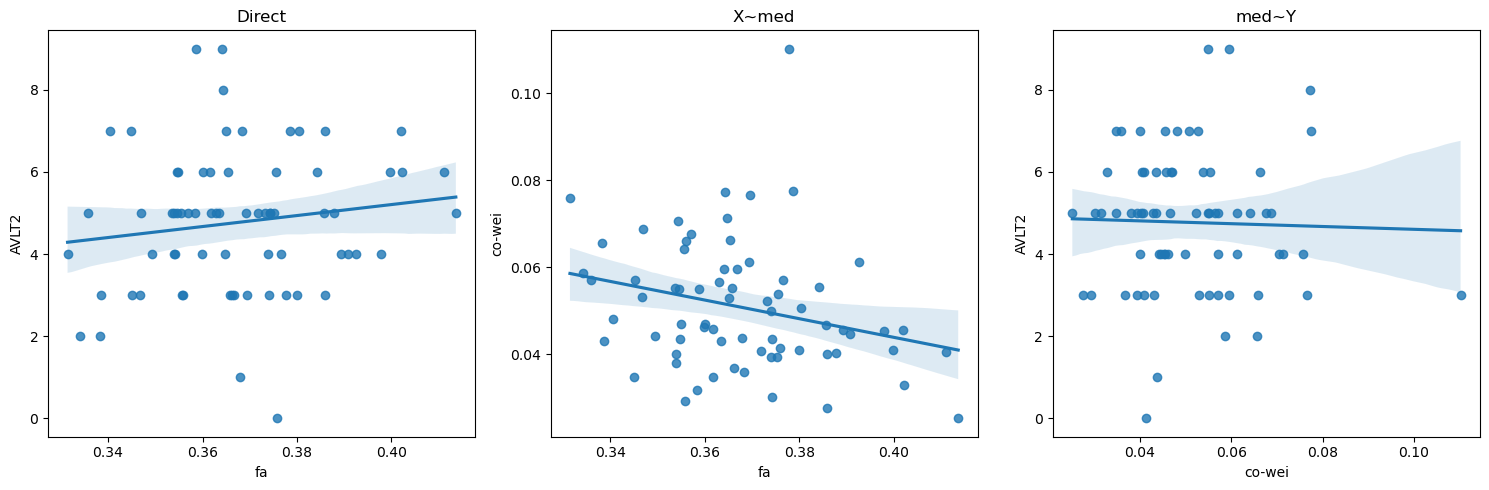

In [11]:
roi_lab = "nawm"
med_items = ["rd", "fa","ad","log"+roi_lab]
cog_items = ["门诊MMSE", "MoCA-merge","TMT(B-A)", 'Stroop A-T', 'Stroop B-T','Stroop C-T',  
       'DS(f+b)', 'DS-forward','DS-backward', 'DSS', 'VFT', 'AVLT1', 'AVLT2', 'AVLT3',
         'AVLT4','AVLT5', 'AVLT再认', 'AVLT(1+2+3)', 'Rey-O回忆', 'Rey-O再认', 'Rey-O复制',
       'BNT']

sum_res = pd.DataFrame()
for med_item in med_items:
    # Global mediation analysis
    for cog_item in cog_items:
        for lm_lab in LM_LAB:
            for cm in ana_utils.CM_ARR[1:]:
                cm_lab, cm_idx, _ = cm
                # print(cog_item, lm, cm_lab)
                df = pd.read_csv(f"{HOME}/results/lr_glob_lm_cfc/{cm_lab}-cfc_{lm_lab}.csv")
                df = df[df.idx ==cm_idx]

                df["age"] = df["pid"].map(ana_utils.SUB_ID_AGE_DICT)
                df["edu_year"] = df["pid"].map(SUB_INFO_TBL.set_index("pid")["edu_year"].to_dict())
                df["cog"] = df["pid"].map(SUB_INFO_TBL.set_index("pid")[cog_item].to_dict())
                df[med_item] = df["pid"].map(SUB_INFO_TBL.set_index("pid")[med_item].to_dict())
                
                df = df[~np.isnan(df['cog'])]
                df= df[df[med_item]>0]
                pg_ma_res = pg.mediation_analysis(data=df, 
                                                  x=med_item, 
                                                  m='rsq', 
                                                  y='cog',
                                                  covar =["age","edu_year"], 
                                                  alpha=0.05,
                                                  n_boot=5000,
                                                    seed=42)
                # Filter results according to the significance 
                sig_list = pg_ma_res.sig.to_list()
                if sig_list[-1] == "Yes" and sig_list[0] == "Yes" and sig_list[1] == "Yes":
                    print(cog_item, cm_lab, lm_lab)
                    pg_ma_res = pg_ma_res.assign(med=med_item, cog=cog_item, lm=lm_lab, cm=cm_lab, net="glob")
                    sum_res = pd.concat([sum_res, pg_ma_res])


    for cog_item in cog_items:
        for net_lab in yeo7_dict.keys():
            for lm_lab in LM_LAB:
                net_df = pd.DataFrame()
                print(cog_item, net_lab, lm_lab)
                for cm in ana_utils.CM_ARR[1:]:
                    
                    cm_name, cm_idx, _ = cm
                    
                    df = pd.read_csv(f"{HOME}/results/corr_net_lm_cfc/{cm_name}-cfc_{lm_lab}.csv")
                    df.cm = cm_name
                    df = df[df.net == net_lab][
                        [
                            "pid",
                            "Group",
                            "cm",
                            "rsq",
                        ]
                    ]
                    net_df = pd.concat([net_df, df], ignore_index=True)

                net_df = pd.merge(net_df, right=SUB_INFO_TBL.set_index("pid")[["age", "edu_year", cog_item, med_item]],on="pid")
                # display(net_df)
                net_df= net_df[net_df[med_item]>0]
                net_pivot_df = net_df.pivot_table(index=['pid', 'Group', 'age',"edu_year", cog_item, med_item], columns='cm', values='rsq').reset_index()
                
                pg_ma_res = pg.mediation_analysis(data=net_pivot_df.copy(), 
                                                  x=med_item, 
                                                  m=CM_NAME_ARR, 
                                                  y=cog_item,
                                                  covar =["age", "edu_year"], 
                                                  alpha=0.05,
                                                  n_boot=5000,
                                seed=42)
                # Filter results according to the significance 
                sig_list = pg_ma_res.sig.to_list()
                issave = False
                for i in range(len(sig_list) - 14):
                    if sig_list[i]== "Yes"  and sig_list[i + 6]== "Yes"  and sig_list[i + 14]== "Yes":
                        issave = True 
                        
                
                if issave:
                    print(net_lab, lm_lab)
                    pg_ma_res = pg_ma_res.assign(med=med_item, cog=cog_item, lm=lm_lab, cm=cm_lab, net=net_lab)
                    sum_res = pd.concat([sum_res, pg_ma_res])
                    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

                    # 第一个图
                    sns.regplot(data=net_pivot_df, x=med_item, y=cog_item, ax=axes[0])
                    axes[0].set_title('Direct')

                    # 第二个图
                    sns.regplot(data=net_pivot_df, x=med_item, y="co-wei", ax=axes[1])
                    axes[1].set_title('X~med')

                    # 第三个图
                    sns.regplot(data=net_pivot_df, x="co-wei", y=cog_item, ax=axes[2])
                    axes[2].set_title('med~Y')

                    plt.tight_layout()  # 确保图表正确排列
                    plt.savefig(f"{HOME}/results/med_{roi_lab}/{med_item}_{cog_item}_{lm_lab}_{net_lab}.png")
sum_res.to_csv(f"{HOME}/results/med_{roi_lab}/mediaction_{roi_lab}.csv")

In [52]:
roi_lab = "wmh"
med_items = ["rd", "fa","ad","log"+roi_lab]
cog_items = ["门诊MMSE", "MoCA-merge","TMT(B-A)", 'Stroop A-T', 'Stroop B-T','Stroop C-T',  
       'DS(f+b)', 'DS-forward','DS-backward',  'AVLT1', 'AVLT2', 'AVLT3',
         'AVLT4','AVLT5', 'AVLT再认',  'Rey-O回忆', 'Rey-O再认','BNT']
# 'DSS', 'VFT', 'Rey-O复制','AVLT(1+2+3)',

sum_res = pd.DataFrame()
for med_item in med_items:
    # Global mediation analysis
    for cog_item in cog_items:
        for lm_lab in LM_LAB:
        
            df_fg = pd.read_csv(f"{HOME}/results/lr_glob_lm_cfc/fg-wei-cfc_{lm_lab}.csv")
            df_fg = df_fg[df_fg.idx ==3].assign(cm="fg-wei")
            df_si = pd.read_csv(f"{HOME}/results/lr_glob_lm_cfc/si-wei-cfc_{lm_lab}.csv")
            df_si = df_si[df_si.idx ==2].assign(cm="si-wei")
            df = pd.concat([df_fg, df_si]).pivot_table(
                values="rsq",index=["pid","Group"],columns ="cm").reset_index()
            df["fgsi"] = df["fg-wei"]/df["si-wei"]
            df["age"] = df["pid"].map(ana_utils.SUB_ID_AGE_DICT)
            df["edu_year"] = df["pid"].map(SUB_INFO_TBL.set_index("pid")["edu_year"].to_dict())
            df["cog"] = df["pid"].map(SUB_INFO_TBL.set_index("pid")[cog_item].to_dict())
            df[med_item] = df["pid"].map(SUB_INFO_TBL.set_index("pid")[med_item].to_dict())
            
            df = df[~np.isnan(df['cog'])]
            df= df[df[med_item]>0]
            pg_ma_res = pg.mediation_analysis(data=df, 
                                                x=med_item, 
                                                m='fgsi', 
                                                y='cog',
                                                covar =["age","edu_year"], 
                                                alpha=0.05,
                                                n_boot=5000,
                                                seed=42)
            # Filter results according to the significance 
            sig_list = pg_ma_res.sig.to_list()
            if sig_list[-1] == "Yes" and sig_list[0] == "Yes" and sig_list[1] == "Yes":
                print(cog_item, cm_lab, lm_lab)
                pg_ma_res = pg_ma_res.assign(med=med_item, cog=cog_item, lm=lm_lab, cm=cm_lab, net="glob")
                sum_res = pd.concat([sum_res, pg_ma_res])


    # for cog_item in cog_items:
    #     for net_lab in yeo7_dict.keys():
    #         for lm_lab in LM_LAB:
    #             net_df = pd.DataFrame()
    #             print(cog_item, net_lab, lm_lab)
    #             for cm in ana_utils.CM_ARR[1:]:
                    
    #                 cm_name, cm_idx, _ = cm
                    
    #                 df = pd.read_csv(f"{HOME}/results/corr_net_lm_cfc/{cm_name}-cfc_{lm_lab}.csv")
    #                 df.cm = cm_name
    #                 df = df[df.net == net_lab][
    #                     [
    #                         "pid",
    #                         "Group",
    #                         "cm",
    #                         "rsq",
    #                     ]
    #                 ]
    #                 net_df = pd.concat([net_df, df], ignore_index=True)

    #             net_df = pd.merge(net_df, right=SUB_INFO_TBL.set_index("pid")[["age", "edu_year", cog_item, med_item]],on="pid")
    #             # display(net_df)
    #             net_df= net_df[net_df[med_item]>0]
    #             net_pivot_df = net_df.pivot_table(index=['pid', 'Group', 'age',"edu_year", cog_item, med_item], columns='cm', values='rsq').reset_index()
                
    #             pg_ma_res = pg.mediation_analysis(data=net_pivot_df.copy(), 
    #                                               x=med_item, 
    #                                               m=CM_NAME_ARR, 
    #                                               y=cog_item,
    #                                               covar =["age", "edu_year"], 
    #                                               alpha=0.05,
    #                                               n_boot=5000,
    #                             seed=42)
    #             # Filter results according to the significance 
    #             sig_list = pg_ma_res.sig.to_list()
    #             issave = False
    #             for i in range(len(sig_list) - 14):
    #                 if sig_list[i]== "Yes"  and sig_list[i + 6]== "Yes"  and sig_list[i + 14]== "Yes":
    #                     issave = True 
                        
                
    #             if issave:
    #                 print(net_lab, lm_lab)
    #                 pg_ma_res = pg_ma_res.assign(med=med_item, cog=cog_item, lm=lm_lab, cm=cm_lab, net=net_lab)
    #                 sum_res = pd.concat([sum_res, pg_ma_res])
    #                 fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    #                 # 第一个图
    #                 sns.regplot(data=net_pivot_df, x=med_item, y=cog_item, ax=axes[0])
    #                 axes[0].set_title('Direct')

    #                 # 第二个图
    #                 sns.regplot(data=net_pivot_df, x=med_item, y="co-wei", ax=axes[1])
    #                 axes[1].set_title('X~med')

    #                 # 第三个图
    #                 sns.regplot(data=net_pivot_df, x="co-wei", y=cog_item, ax=axes[2])
    #                 axes[2].set_title('med~Y')

    #                 plt.tight_layout()  # 确保图表正确排列
    #                 plt.savefig(f"{HOME}/results/med_{roi_lab}/{med_item}_{cog_item}_{lm_lab}_{net_lab}.png")

sum_res.to_csv(f"{HOME}/results/med_{roi_lab}/mediaction_fgsi_{roi_lab}.csv")

In [53]:
stop here

SyntaxError: invalid syntax (4067800170.py, line 1)

In [ ]:

for cog_item in ["门诊MMSE", "MoCA-merge"]:
    print(cog_item)
    for lm in LM_LAB:
        for cm in CM_ARR:
            cm_name, cm_idx, _ = cm
            print(cog_item, lm,cm_name)
            df = pd.read_csv(f"{HOME}/results/lr_net_lm_cfc/{cm_name}-cfc_{lm}.csv")
            
            df = df[df.idx ==cm_idx]
            
            df = pd.merge(df, right=SUB_INFO_TBL.set_index("pid")[["age", "edu_year", cog_item, med_item]],on="pid")
            
            df = df[~np.isnan(df[cog_item])]
            # df= df[df[med_item]>0]
            
            df = df.pivot_table(index=['pid', 'Group', 'cm', 'idx', 'age', "edu_year", cog_item ,med_item], columns='net', values='rsq').reset_index()
            
            res = pg.mediation_analysis(data=df, x=med_item, m=list(yeo7_dict.keys()), y=cog_item,covar =["age","edu_year"], alpha=0.05,
                            seed=42)
            # display(res[res.sig=="Yes"])
            anyindirect = res.sig[-6:].to_list()
            if "Yes" in anyindirect:
                print(cm_name, lm)
                display(res[res.sig=="Yes"])
                    

In [ ]:
stop

NameError: name 'stop' is not defined

# correlation 

In [ ]:

# Get sub_info tbl
SUB_INFO_TBL =pd.read_csv(f"{HOME}/data/filt_sub_info.csv",encoding="gbk")
mean_edu_year = SUB_INFO_TBL['edu_year'].mean().round()
# Fill education year nan to mean
SUB_INFO_TBL['edu_year'].fillna(mean_edu_year, inplace=True)

# Get NAWM volume
nawm_tbl = pd.read_csv(f"{HOME}/results/lms_stat/nawm_volume_raw.csv",names=["pid","nawm"])
nawm_tbl["lognawm"] = nawm_tbl["nawm"].apply(lambda x: np.log(x))
SUB_INFO_TBL = pd.merge(SUB_INFO_TBL, on="pid",right=nawm_tbl)

wmh_met_tbl = pd.read_csv(f"{HOME}/results/lms_stat/2_wmh_dwi_metric.csv",names=["pid","dwim","val"])
wmh_met_pivot = wmh_met_tbl.pivot_table(index="pid",values="val",columns="dwim").reset_index()
SUB_INFO_TBL = pd.merge(SUB_INFO_TBL, on="pid",right=wmh_met_pivot)
# SUB_INFO_TBL.columns

In [ ]:
med_items = ["rd", "fa","ad","adc","logwmh","lognawm"]
sum_res = pd.DataFrame()
for med_item in med_items:
    # Global mediation analysis
    for cog_item in ["门诊MMSE", "MoCA-merge"]:
        for lm_lab in LM_LAB:
            for cm in ana_utils.CM_ARR[1:]:
                cm_lab, cm_idx, _ = cm
                # print(cog_item, lm, cm_lab)
                df = pd.read_csv(f"{HOME}/results/lr_glob_lm_cfc/{cm_lab}-cfc_{lm_lab}.csv")
                df = df[df.idx ==cm_idx]

                df["age"] = df["pid"].map(ana_utils.SUB_ID_AGE_DICT)
                df["edu_year"] = df["pid"].map(SUB_INFO_TBL.set_index("pid")["edu_year"].to_dict())
                df["cog"] = df["pid"].map(SUB_INFO_TBL.set_index("pid")[cog_item].to_dict())
                df[med_item] = df["pid"].map(SUB_INFO_TBL.set_index("pid")[med_item].to_dict())
                
                df = df[~np.isnan(df['cog'])]
                df= df[df[med_item]>0]
                pg_ma_res = pg.mediation_analysis(data=df, x=med_item, m='rsq', y='cog',covar =["age","edu_year"], alpha=0.05,
                                seed=42)
                if pg_ma_res.sig.to_list()[-1]=="Yes":
                    print(cog_item, cm_lab, lm_lab)
                    pg_ma_res = pg_ma_res.assign(med=med_item, cog=cog_item, lm=lm_lab, cm=cm_lab, net="glob")
                    sum_res = pd.concat([sum_res, pg_ma_res])


    for cog_item in ["门诊MMSE", "MoCA-merge"]:
        for net_lab in yeo7_dict.keys():
            for lm_lab in LM_LAB:
                net_df = pd.DataFrame()
                print(cog_item, net_lab, lm_lab)
                for cm in ana_utils.CM_ARR[1:]:
                    
                    cm_name, cm_idx, _ = cm
                    
                    df = pd.read_csv(f"{HOME}/results/corr_net_lm_cfc/{cm_name}-cfc_{lm_lab}.csv")
                    df.cm = cm_name
                    df = df[df.net == net_lab][
                        [
                            "pid",
                            "Group",
                            "cm",
                            "rsq",
                        ]
                    ]
                    net_df = pd.concat([net_df, df], ignore_index=True)

                net_df = pd.merge(net_df, right=SUB_INFO_TBL.set_index("pid")[["age", "edu_year", cog_item, med_item]],on="pid")
                # display(net_df)
                net_df= net_df[net_df[med_item]>0]
                net_pivot_df = net_df.pivot_table(index=['pid', 'Group', 'age',"edu_year", cog_item, med_item], columns='cm', values='rsq').reset_index()
                
                pg_ma_res = pg.mediation_analysis(data=net_pivot_df.copy(), x=med_item, m=CM_NAME_ARR, y=cog_item,covar =["age", "edu_year"], alpha=0.05,
                                seed=42)
                
                anyindirect = pg_ma_res.sig[-6:].to_list()
                if "Yes" in anyindirect:
                    print(net_lab, lm_lab)
                    pg_ma_res = pg_ma_res.assign(med=med_item, cog=cog_item, lm=lm_lab, cm=cm_lab, net=net_lab)
                    sum_res = pd.concat([sum_res, pg_ma_res])
                    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

                    # 第一个图
                    sns.regplot(data=net_pivot_df, x=med_item, y=cog_item, ax=axes[0])
                    axes[0].set_title('Direct')

                    # 第二个图
                    sns.regplot(data=net_pivot_df, x=med_item, y="si-wei", ax=axes[1])
                    axes[1].set_title('X~med')

                    # 第三个图
                    sns.regplot(data=net_pivot_df, x="si-wei", y=cog_item, ax=axes[2])
                    axes[2].set_title('med~Y')

                    plt.tight_layout()  # 确保图表正确排列
                    plt.savefig(f"{HOME}/results/{med_item}_{cog_item}_{lm_lab}_{net_lab}_plwei.png")
sum_res.to_csv(f"{HOME}/results/mediaction_{med_item}.csv")

# Plot meadiation Sankey

In [ ]:
import plotly.graph_objects as go
med_res_wmh_tbl = pd.read_csv(f"{HOME}/results/med_wmh1000/mediaction_wmh.csv")
med_res_nawm_tbl = pd.read_csv(f"{HOME}/results/med_nawm1000/mediaction_nawm.csv")
med_res_tbl = pd.concat([med_res_wmh_tbl, med_res_nawm_tbl[med_res_nawm_tbl.med =="lognawm"]])


In [ ]:
med_res_tbl = med_res_nawm_tbl
med_res_nawm_tbl = med_res_nawm_tbl.sort_values(by="path",axis=0)
med_res_tbl =  med_res_tbl[~med_res_tbl.cog.isin(["DSS","AVLT(1+2+3)","Rey-O回忆"])]
# med_res_tbl = med_res_tbl[ (med_res_tbl.path.str.contains("~"))]

# (med_res_tbl.sig=="Yes") & 
med_res_tbl = med_res_tbl[med_res_tbl.net!="glob"]
rep_item_arr = [["Rey-O再认", "Rey-O-recall"],
                ["MoCA-merge", "MoCA"],
                ["Rey-O复制", "Rey-O-copy"],]
for rep_item in rep_item_arr:
    med_res_tbl.cog = med_res_tbl.cog.str.replace(*rep_item)
med_res_tbl.med = med_res_tbl.med.str.replace("rd", "RD")
med_res_tbl.med = med_res_tbl.med.str.replace("ad", "AD")
med_res_tbl.med = med_res_tbl.med.str.replace("logwmh", "Volume")

In [ ]:
# Color
opaque_color = [
    "rgba(250, 127, 111, 1)",
    "rgba(255, 190, 122, 1)",
    "rgba(130, 176, 210, 1)"
]
trans_color=[
    "rgba(250, 127, 111, 0.3)",
    "rgba(255, 190, 122, 0.3)",
    "rgba(130, 176, 210, 0.3)"
]

In [ ]:

for j, lm_lab in enumerate(LM_LAB):
    med_res_lm = med_res_tbl[med_res_tbl.lm == lm_lab]
    # display(med_res_lm[med_res_lm.path.str.contains("fg")])
    y_labs = med_res_lm.cog.unique()
    x_labs = med_res_lm.med.unique()
    cm_by_net = []
    for cm in CM_NAME_ARR:
        for net in med_res_lm.net.unique():
            cm_by_net.append(cm[:2].upper()+"-"+network_abbreviations[net])

    sankey_labs = [*x_labs, *cm_by_net, *y_labs]
    sankey_labs_color = [*[PLT3[1] for i in x_labs ]]

    for cm in cm_by_net:
        for cm_cl in CM_ARR:
            if cm[:2].lower()==cm_cl[0][:2]:

                sankey_labs_color.append(cm_cl[2])
    
    sankey_labs_color = [*sankey_labs_color,
                         *[PLT3[1] for i in y_labs ]]
    # pos_x_arr = [*[0 for i in x_labs], *[0.5 for i in cm_by_net], *[1 for i in y_labs]]
    print(sankey_labs)
    link_dict = dict(
        source = [],
        target = [],
        value = [],
        line=[],
        color = [],
    )
    node_dict = dict(
        pad = 10,
        thickness = 50,
        line = dict(color = "black", width = 0.0),
        label = sankey_labs,
        color =sankey_labs_color
        )
    for j in range(len(med_res_lm)//20):
            
        for index in range(6):
            row = med_res_lm.iloc[20*j+index]
            
            
            cm_x_y = row["path"].split(" ~ ")
            med_cm = cm_x_y[0]
            link_dict["source"].append(sankey_labs.index(row["med"]))
            link_dict["target"].append(sankey_labs.index(med_cm[:2].upper()+"-"+network_abbreviations[row["net"]]))
            link_dict["value"].append(1)


            line_cl = "white" if row.sig =="Yes" else "rgba(0,0,0,0)"
            link_dict["line"] = dict(color = line_cl, width = 0)
            if med_res_lm.iloc[20*j+index+6+8].sig == "Yes":
                link_cl = opaque_color[0] if row.coef > 0 else opaque_color[2]
            else:
                if row.sig =="Yes":
                    link_cl = trans_color[0] if row.coef > 0 else trans_color[2]
                else:
                    link_cl ="rgba(0, 0, 0, 0.03)"
            link_dict["color"].append(link_cl)


            row = med_res_lm.iloc[20*j+index+6]
            cm_x_y = row["path"].split(" ~ ")
            med_cm = cm_x_y[1]
            
            link_dict["source"].append(sankey_labs.index(med_cm[:2].upper()+"-"+network_abbreviations[row["net"]]))
            link_dict["target"].append(sankey_labs.index(row["cog"]))
            
            link_dict["value"].append(1)


            line_cl = "white" if row.sig =="Yes" else "rgba(0,0,0,0)"
            link_dict["line"] = dict(color = line_cl, width = 0)
            if med_res_lm.iloc[20*j+index+6+8].sig == "Yes":
                link_cl = opaque_color[0] if row.coef > 0 else opaque_color[2]
            else:
                if row.sig =="Yes":
                    link_cl = trans_color[0] if row.coef > 0 else trans_color[2]
                else:
                    link_cl ="rgba(0, 0, 0, 0.03)"
            link_dict["color"].append(link_cl)
            


    fig = go.Figure(data=[go.Sankey(
        node = node_dict,
        link = link_dict)])

    fig.update_layout(title_text="", font_size=15)
    fig.show()

    # fig.write_image(f"{HOME}/figures/sankey-{lm_lab}.svg", format="svg", scale=1)

['RD', 'AD', 'lognawm', 'MF-DMN', 'MF-FPC', 'MF-VAN', 'FG-DMN', 'FG-FPC', 'FG-VAN', 'CO-DMN', 'CO-FPC', 'CO-VAN', 'PT-DMN', 'PT-FPC', 'PT-VAN', 'SI-DMN', 'SI-FPC', 'SI-VAN', 'PL-DMN', 'PL-FPC', 'PL-VAN', 'AVLT2', 'AVLT4', 'AVLT再认', 'Rey-O-copy', 'MoCA', 'AVLT3', 'Rey-O-recall']


['RD', 'AD', 'lognawm', 'MF-VAN', 'MF-FPC', 'MF-DAN', 'MF-DMN', 'FG-VAN', 'FG-FPC', 'FG-DAN', 'FG-DMN', 'CO-VAN', 'CO-FPC', 'CO-DAN', 'CO-DMN', 'PT-VAN', 'PT-FPC', 'PT-DAN', 'PT-DMN', 'SI-VAN', 'SI-FPC', 'SI-DAN', 'SI-DMN', 'PL-VAN', 'PL-FPC', 'PL-DAN', 'PL-DMN', 'Stroop B-T', 'AVLT1', 'AVLT2', 'AVLT3', 'AVLT4', 'Rey-O-recall']


['RD', 'AD', 'MF-DMN', 'MF-DAN', 'FG-DMN', 'FG-DAN', 'CO-DMN', 'CO-DAN', 'PT-DMN', 'PT-DAN', 'SI-DMN', 'SI-DAN', 'PL-DMN', 'PL-DAN', 'AVLT1', 'Rey-O-recall']
